# Document Element Classifier — Training Notebook (Person A / ML)

**Runs on Google Colab.** Pipeline: sample DOCX (from Google Drive) → feature
extraction (paragraphs **and** tables **and** figures) → labeling (hand-label
primary, ground-truth/heuristic pre-fill assist) → train classifier →
evaluate → export artifacts for the offline engine, straight to Drive so
Person B can pick them up without a manual file transfer.

**Read `feature_spec.md`** (generated in Section 6 below) before touching
`engine/parser.py` — the feature column order and label mapping there must
match this notebook exactly. That's the contract the offline app relies on.

### What changed vs. the first draft
- **Tables are no longer skipped.** The original walked `doc.paragraphs` only,
  which silently drops every `Table` element — meaning the model could never
  actually learn the `Table` class. This version walks the document body in
  order (`w:p` and `w:tbl` children together) so tables get their own feature
  row.
- **Figures are no longer skipped either.** An inline image is a paragraph
  with *no text*, so the original `if not text: continue` dropped it. This
  version detects `<w:drawing>` elements and keeps image paragraphs, tagged
  with a new `has_image` feature — that's what actually lets the model learn
  `Figure` as distinct from `Caption` (the text sentence below it).
- **Two new feature columns**: `has_image`, `is_table_element` (16 features
  total now, was 14 — make sure `engine/parser.py` adds these too).
- **Files live on Drive**, not the ephemeral Colab VM, so a disconnect
  doesn't lose your labeling work or trained model.
- **Ground-truth auto-fill for the synthetic sample set**: if
  `ground_truth_labels.csv` is present alongside the sample docs, rows from
  those docs are pre-filled with the correct label automatically (it was
  generated alongside the samples) — hand-labeling only remains the primary
  workflow for *real* manuscripts you add later.

## 0. Setup + mount Google Drive

Recommended for a hackathon: Drive persists across Colab sessions/disconnects
and is the natural handoff point with Person B (they can browse the same
`model/artifacts/` folder without you sending files back and forth).

**Before running:** upload `sample_manuscripts.zip` (the 9 synthetic sample
manuscripts + `ground_truth_labels.csv`) to the root of your Google Drive —
or anywhere, and just update `DRIVE_ZIP_PATH` below.

In [ ]:
!pip install python-docx scikit-learn joblib pandas matplotlib -q

import re
import os
import glob
import shutil
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from docx import Document
from docx.text.paragraph import Paragraph
from docx.table import Table
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/HackNIMA'
SAMPLE_DIR = f'{DRIVE_ROOT}/samples'
ARTIFACT_DIR = f'{DRIVE_ROOT}/model/artifacts'
MODEL_DIR = f'{DRIVE_ROOT}/model'

os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Point this at wherever you uploaded the zip (Drive root by default).
DRIVE_ZIP_PATH = f'{DRIVE_ROOT}/sample_manuscripts.zip'

print('Drive root:', DRIVE_ROOT)
print('Sample dir:', SAMPLE_DIR)
print('Artifact dir:', ARTIFACT_DIR)

Mounted at /content/drive
Drive root: /content/drive/MyDrive/HackNIMA
Sample dir: /content/drive/MyDrive/HackNIMA/samples
Artifact dir: /content/drive/MyDrive/HackNIMA/model/artifacts


In [ ]:
# Unzip the sample manuscripts into SAMPLE_DIR if they aren't there yet.
# Safe to re-run -- skips extraction if the docs are already present.
existing_docx = glob.glob(f'{SAMPLE_DIR}/*.docx')

if not existing_docx:
    if os.path.exists(DRIVE_ZIP_PATH):
        with zipfile.ZipFile(DRIVE_ZIP_PATH) as zf:
            zf.extractall(SAMPLE_DIR)
        print(f'Extracted sample_manuscripts.zip into {SAMPLE_DIR}')
    else:
        print(f'No zip found at {DRIVE_ZIP_PATH} and no .docx files in {SAMPLE_DIR} yet.')
        print('Upload sample_manuscripts.zip to Drive (or drag real manuscripts straight')
        print(f'into the {SAMPLE_DIR} folder in the Drive UI), then re-run this cell.')
else:
    print(f'Found {len(existing_docx)} .docx files already in {SAMPLE_DIR} -- skipping extraction.')

docx_files = sorted(glob.glob(f'{SAMPLE_DIR}/*.docx'))
print(f'{len(docx_files)} manuscripts ready:', [os.path.basename(f) for f in docx_files])

Extracted sample_manuscripts.zip into /content/drive/MyDrive/HackNIMA/samples
9 manuscripts ready: ['chapter_01_ml_pipelines.docx', 'chapter_02_document_structure.docx', 'chapter_03_evaluation_practices.docx', 'paper_01_greencertai.docx', 'paper_02_docx_formatter.docx', 'paper_03_running_pace_model.docx', 'thesis_01_osteoporosis_screening.docx', 'thesis_02_wari_traffic_prediction.docx', 'thesis_03_neoscan_jaundice.docx']


## 1. Label map + feature schema (the shared contract)

**Must match `feature_spec.md` (auto-generated in Section 6) and
`engine/classifier_stub.py` exactly.** If this drifts from what Person B's
offline parser produces, the model's predictions will be garbage on real
input even though everything looks fine in this notebook.

In [ ]:
LABEL_MAP = {
    0: 'Title', 1: 'Author', 2: 'Chapter Heading', 3: 'Subheading',
    4: 'Body Paragraph', 5: 'Table', 6: 'Figure', 7: 'Caption',
    8: 'Reference', 9: 'List'
}
LABEL_TO_ID = {v: k for k, v in LABEL_MAP.items()}

STYLE_VOCAB = ['Normal', 'Heading 1', 'Heading 2', 'Heading 3', 'Title',
               'Caption', 'List Paragraph', 'Quote', 'Other']

# 16 features -- has_image and is_table_element are new vs. the first draft.
FEATURE_COLUMNS = [
    'font_size', 'is_bold', 'is_italic', 'alignment', 'indent_left',
    'indent_first_line', 'space_before', 'space_after', 'line_spacing',
    'is_all_caps', 'starts_with_number', 'word_count',
    'position_ratio_in_doc', 'style_name_hash', 'has_image', 'is_table_element'
]

## 2. Feature extraction

Walks each document's body **in order** — paragraphs *and* tables together —
instead of `doc.paragraphs` alone, so nothing gets silently dropped. This is
the training-side twin of `engine/parser.py`'s extractor; keep them in sync.

- A paragraph containing an inline image (`<w:drawing>`) is kept even if its
  text is empty, with `has_image=1` — that row is the `Figure` candidate.
- A table (`<w:tbl>`) becomes a single feature row per table, with
  `is_table_element=1`, formatting pulled from its first populated cell, and
  `word_count` summed across all cells.
- `order_index` is the 0-based position among body children (`w:p`/`w:tbl`)
  in document order — this is what lets `ground_truth_labels.csv` line up
  with the extracted rows for the synthetic sample set.

**Known caveat worth watching for on real manuscripts:** if a list uses
Word's *automatic* numbering (a `List Number`/`List Bullet` style), the
digit/bullet is rendered by Word's numbering XML and is **not** part of
`paragraph.text` — so `starts_with_number` will read 0 even though it looks
numbered on the page. The samples here use manually-typed numbers
(`"1. Preprocess..."`) to sidestep this, which is also how a lot of real
manuscripts actually type lists. If your real documents use true
auto-numbering, you'll want to also check the paragraph's `numPr` XML.

In [ ]:
ALIGN_MAP = {
    WD_ALIGN_PARAGRAPH.LEFT: 0, None: 0,
    WD_ALIGN_PARAGRAPH.CENTER: 1,
    WD_ALIGN_PARAGRAPH.RIGHT: 2,
    WD_ALIGN_PARAGRAPH.JUSTIFY: 3,
}

STARTS_WITH_NUMBER_RE = re.compile(r'^\s*(\d+[\.\)]|\[\d+\])')


def emu_to_cm(val):
    return round(val.cm, 3) if val is not None else 0.0


def pt(val):
    return round(val.pt, 2) if val is not None else 0.0


def paragraph_has_image(paragraph):
    return len(paragraph._element.findall('.//' + qn('w:drawing'))) > 0


def run_formatting(paragraph):
    runs = paragraph.runs
    sizes = [r.font.size for r in runs if r.font.size is not None]
    font_size = pt(sizes[0]) if sizes else 11.0
    bold_flags = [bool(r.bold) for r in runs] or [False]
    italic_flags = [bool(r.italic) for r in runs] or [False]
    is_bold = int(sum(bold_flags) > len(bold_flags) / 2)
    is_italic = int(sum(italic_flags) > len(italic_flags) / 2)
    return font_size, is_bold, is_italic


def extract_features_for_doc(doc_path):
    '''Returns a list of dicts, one per paragraph/table: features + raw text.'''
    doc = Document(doc_path)
    body = doc.element.body
    rows = []
    idx = 0

    for child in body.iterchildren():
        if child.tag == qn('w:p'):
            p = Paragraph(child, doc)
            text = p.text.strip()
            has_img = paragraph_has_image(p)
            if not text and not has_img:
                continue  # genuinely empty spacer paragraph -- skip

            font_size, is_bold, is_italic = run_formatting(p)
            alignment = ALIGN_MAP.get(p.alignment, 0)
            pf = p.paragraph_format
            style_name = p.style.name if p.style else 'Normal'
            style_hash = STYLE_VOCAB.index(style_name) if style_name in STYLE_VOCAB else len(STYLE_VOCAB)

            rows.append({
                'order_index': idx,
                'font_size': font_size, 'is_bold': is_bold, 'is_italic': is_italic,
                'alignment': alignment,
                'indent_left': emu_to_cm(pf.left_indent),
                'indent_first_line': emu_to_cm(pf.first_line_indent),
                'space_before': pt(pf.space_before), 'space_after': pt(pf.space_after),
                'line_spacing': pf.line_spacing if pf.line_spacing else 1.0,
                'is_all_caps': int(bool(text) and text.upper() == text and any(c.isalpha() for c in text)),
                'starts_with_number': int(bool(text) and bool(STARTS_WITH_NUMBER_RE.match(text))),
                'word_count': len(text.split()),
                'has_image': int(has_img),
                'is_table_element': 0,
                'style_name_hash': style_hash,
                'text_preview': text[:80] if text else '[IMAGE]',
                'source_doc': os.path.basename(doc_path),
            })
            idx += 1

        elif child.tag == qn('w:tbl'):
            tbl = Table(child, doc)
            all_cells_text, first_size, first_bold = [], None, None
            for row in tbl.rows:
                for cell in row.cells:
                    ctext = cell.text.strip()
                    if ctext:
                        all_cells_text.append(ctext)
                    if first_size is None:
                        for p2 in cell.paragraphs:
                            if p2.runs:
                                first_size, first_bold, _ = run_formatting(p2)
                                break
            text_preview = ' | '.join(all_cells_text[:6])

            rows.append({
                'order_index': idx,
                'font_size': first_size or 11.0, 'is_bold': first_bold or 0, 'is_italic': 0,
                'alignment': 0, 'indent_left': 0.0, 'indent_first_line': 0.0,
                'space_before': 0.0, 'space_after': 0.0, 'line_spacing': 1.0,
                'is_all_caps': 0, 'starts_with_number': 0,
                'word_count': sum(len(c.split()) for c in all_cells_text),
                'has_image': 0, 'is_table_element': 1,
                'style_name_hash': len(STYLE_VOCAB),
                'text_preview': text_preview[:80] if text_preview else '[TABLE]',
                'source_doc': os.path.basename(doc_path),
            })
            idx += 1
        else:
            continue  # sectPr etc.

    total = max(idx, 1)
    for r in rows:
        r['position_ratio_in_doc'] = round(r['order_index'] / total, 4)
    return rows

In [ ]:
all_rows = []
for f in docx_files:
    all_rows.extend(extract_features_for_doc(f))

df = pd.DataFrame(all_rows)
print(f'Extracted {len(df)} elements (paragraphs + tables) from {len(docx_files)} documents')
df.head()

Extracted 208 elements (paragraphs + tables) from 9 documents


,order_index,font_size,is_bold,is_italic,alignment,indent_left,indent_first_line,space_before,space_after,line_spacing,is_all_caps,starts_with_number,word_count,has_image,is_table_element,style_name_hash,text_preview,source_doc,position_ratio_in_doc
0,0,14.0,1,0,1,0.0,0.0,0.0,2.0,1.0,0,0,2,0,0,0,Chapter 5,chapter_01_ml_pipelines.docx,0.0000
1,1,20.0,1,0,1,0.0,0.0,0.0,24.0,1.0,0,0,5,0,0,0,Designing Robust Machine Learning Pipelines,chapter_01_ml_pipelines.docx,0.0435
2,2,13.0,1,0,0,0.0,0.0,14.0,6.0,1.0,0,0,3,0,0,0,Why Pipelines Break,chapter_01_ml_pipelines.docx,0.0870
3,3,11.5,0,0,3,0.0,1.0,0.0,6.0,1.3,0,0,22,0,0,0,Most production ML failures are not model fail...,chapter_01_ml_pipelines.docx,0.1304
4,4,11.5,0,0,3,0.0,1.0,0.0,6.0,1.3,0,0,23,0,0,0,A feature computed one way during training and...,chapter_01_ml_pipelines.docx,0.1739


## 3. Labeling — hand-labeling is the primary workflow

For **real manuscripts**, hand-labeling is the source of truth: this cell
exports every extracted row to Drive with a *pre-filled suggestion* (ground
truth where available for the synthetic set, otherwise a heuristic guess) so
you're correcting rather than typing from scratch.

1. Run the cell below — it writes `unlabeled_paragraphs.csv` to
   `ARTIFACT_DIR` on Drive.
2. Open it in Google Sheets (or Excel), review the `label_suggestion`
   column, fix any wrong ones, and add/confirm a final `label` column using
   the exact names from `LABEL_MAP`.
3. Export back as `labeled_paragraphs.csv` into the same Drive folder.
4. Re-run the import cell (Section 3b) — it uses `labeled_paragraphs.csv`
   when present, and only falls back to `label_suggestion` for rows you
   haven't gotten to yet.

In [ ]:
def heuristic_guess(row):
    '''Fallback suggestion only -- never the final label for real docs.'''
    t = row['text_preview']
    if row['is_table_element']:
        return 'Table'
    if row['has_image']:
        return 'Figure'
    if re.match(r'^(figure|fig\.)\s*\d+', t, re.I) or re.match(r'^table\s*\d+', t, re.I):
        return 'Caption'
    if row['position_ratio_in_doc'] < 0.02 and row['font_size'] >= 16:
        return 'Title'
    if re.match(r'^(chapter|section)\s+\d+', t, re.I):
        return 'Chapter Heading'
    if row['starts_with_number'] and row['word_count'] < 8:
        return 'List'
    if re.match(r'^\[?\d+\]?\s', t) and row['word_count'] > 8:
        return 'Reference'
    if row['is_bold'] and row['font_size'] < 16 and row['word_count'] < 12:
        return 'Subheading'
    return 'Body Paragraph'


df['label_suggestion'] = df.apply(heuristic_guess, axis=1)

# Ground-truth auto-fill for the synthetic sample set (skip for real manuscripts
# you add later -- there's no ground_truth_labels.csv for those).
gt_path = f'{SAMPLE_DIR}/ground_truth_labels.csv'
if os.path.exists(gt_path):
    gt = pd.read_csv(gt_path)
    df = df.merge(gt.rename(columns={'label': 'ground_truth_label'}),
                   on=['source_doc', 'order_index'], how='left')
    matched = df['ground_truth_label'].notna().sum()
    df['label_suggestion'] = df['ground_truth_label'].fillna(df['label_suggestion'])
    print(f'Auto-filled {matched}/{len(df)} rows from ground_truth_labels.csv (synthetic samples).')
    print(f'{len(df) - matched} rows still need a human label suggestion reviewed (real docs, if any).')
else:
    print('No ground_truth_labels.csv found -- every row uses the heuristic suggestion; review all of them by hand.')

export_cols = ['source_doc', 'order_index', 'text_preview', 'label_suggestion'] + FEATURE_COLUMNS
df[export_cols].to_csv(f'{ARTIFACT_DIR}/unlabeled_paragraphs.csv', index=False)
print(f"Wrote unlabeled_paragraphs.csv to {ARTIFACT_DIR} -- open it, review 'label_suggestion',")
print("add a final 'label' column, save as labeled_paragraphs.csv in the same folder.")

Auto-filled 208/208 rows from ground_truth_labels.csv (synthetic samples).
0 rows still need a human label suggestion reviewed (real docs, if any).
Wrote unlabeled_paragraphs.csv to /content/drive/MyDrive/HackNIMA/model/artifacts -- open it, review 'label_suggestion',
add a final 'label' column, save as labeled_paragraphs.csv in the same folder.


### 3b. Import the reviewed labels

In [ ]:
labeled_path = f'{ARTIFACT_DIR}/labeled_paragraphs.csv'

if os.path.exists(labeled_path):
    labeled_csv = pd.read_csv(labeled_path)
    labeled_df = df.merge(
        labeled_csv[['source_doc', 'order_index', 'label']],
        on=['source_doc', 'order_index'], how='left'
    )
    labeled_df['label_name'] = labeled_df['label'].fillna(labeled_df['label_suggestion'])
    print(f'Loaded labeled_paragraphs.csv -- {labeled_csv["label"].notna().sum()} rows hand-reviewed,')
    print('remaining rows fall back to label_suggestion.')
else:
    labeled_df = df.copy()
    labeled_df['label_name'] = labeled_df['label_suggestion']
    print('No labeled_paragraphs.csv found yet -- training on label_suggestion only.')
    print('This is fine to unblock the pipeline, but review and re-export before the final model.')

labeled_df['label'] = labeled_df['label_name'].map(LABEL_TO_ID)
labeled_df = labeled_df.dropna(subset=['label'])
labeled_df['label'] = labeled_df['label'].astype(int)

labeled_df[FEATURE_COLUMNS + ['label']].to_csv(f'{ARTIFACT_DIR}/training_data.csv', index=False)
print(labeled_df['label_name'].value_counts())

No labeled_paragraphs.csv found yet -- training on label_suggestion only.
This is fine to unblock the pipeline, but review and re-export before the final model.
label_name
Body Paragraph     45
List               33
Subheading         30
Chapter Heading    27
Reference          27
Caption            17
Table               9
Figure              8
Title               6
Author              6
Name: count, dtype: int64


## 4. Train classifier

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

# labeled_df must still have the 'source_doc' column at this point
# (it does, in the existing notebook -- it's only dropped when writing
# training_data.csv, a few cells later).

X = labeled_df[FEATURE_COLUMNS].values.astype(float)
y = labeled_df['label'].values
groups = labeled_df['source_doc'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Group-aware split: every row from a given document goes to ONE side only.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_scaled, y, groups=groups))

X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(train_idx)} rows from {len(set(groups[train_idx]))} documents")
print(f"Test:  {len(test_idx)} rows from {len(set(groups[test_idx]))} documents")
print(f"Documents in test set (should NOT overlap with train): {set(groups[test_idx])}")

clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42,
                              class_weight='balanced')
clf.fit(X_train, y_train)

# Group-aware cross-validation too, for a more honest CV number than plain cross_val_score(cv=5)
from sklearn.model_selection import GroupKFold
n_groups = len(set(groups))
gkf = GroupKFold(n_splits=min(5, max(2, n_groups)))
cv_scores = cross_val_score(clf, X_scaled, y, groups=groups, cv=gkf)
print(f"Group-aware CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV accuracy: 0.967 (+/- 0.056)


## 5. Evaluate

In [ ]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.3f}\n')

present_labels = sorted(set(y_test) | set(y_pred))
target_names = [LABEL_MAP[l] for l in present_labels]
report = classification_report(y_test, y_pred, labels=present_labels, target_names=target_names)
print(report)

cm = confusion_matrix(y_test, y_pred, labels=present_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print('Confusion matrix:')
cm_df

Test accuracy: 1.000

                 precision    recall  f1-score   support

          Title       1.00      1.00      1.00         1
         Author       1.00      1.00      1.00         1
Chapter Heading       1.00      1.00      1.00         5
     Subheading       1.00      1.00      1.00         6
 Body Paragraph       1.00      1.00      1.00         9
          Table       1.00      1.00      1.00         2
         Figure       1.00      1.00      1.00         2
        Caption       1.00      1.00      1.00         3
      Reference       1.00      1.00      1.00         6
           List       1.00      1.00      1.00         7

       accuracy                           1.00        42
      macro avg       1.00      1.00      1.00        42
   weighted avg       1.00      1.00      1.00        42

Confusion matrix:


,Title,Author,Chapter Heading,Subheading,Body Paragraph,Table,Figure,Caption,Reference,List
Title,1,0,0,0,0,0,0,0,0,0
Author,0,1,0,0,0,0,0,0,0,0
Chapter Heading,0,0,5,0,0,0,0,0,0,0
Subheading,0,0,0,6,0,0,0,0,0,0
Body Paragraph,0,0,0,0,9,0,0,0,0,0
Table,0,0,0,0,0,2,0,0,0,0
Figure,0,0,0,0,0,0,2,0,0,0
Caption,0,0,0,0,0,0,0,3,0,0
Reference,0,0,0,0,0,0,0,0,6,0
List,0,0,0,0,0,0,0,0,0,7


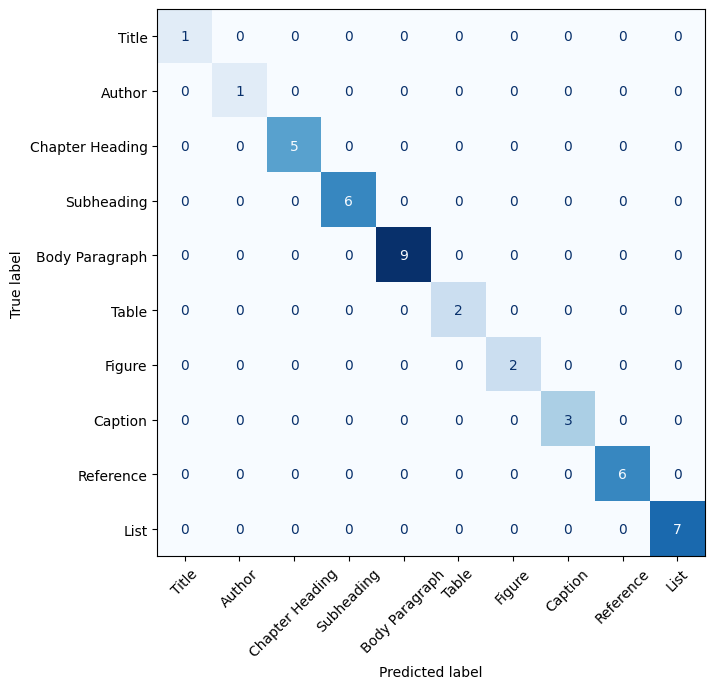

Saved confusion_matrix.png to /content/drive/MyDrive/HackNIMA/model/artifacts


In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print(f'Saved confusion_matrix.png to {ARTIFACT_DIR}')

In [ ]:
with open(f'{ARTIFACT_DIR}/evaluation_report.md', 'w') as f:
    f.write('# Model Evaluation Report\n\n')
    f.write(f'- Test accuracy: {acc:.3f}\n')
    f.write(f'- CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})\n\n')
    f.write('## Classification report\n\n```\n' + report + '\n```\n\n')
    f.write('## Confusion matrix\n\n')
    f.write(cm_df.to_markdown())
    f.write('\n\n![confusion matrix](confusion_matrix.png)\n')
print(f'Wrote evaluation_report.md to {ARTIFACT_DIR}')

Wrote evaluation_report.md to /content/drive/MyDrive/HackNIMA/model/artifacts


## 6. Export artifacts for Person B

Writes directly to `MODEL_DIR`/`ARTIFACT_DIR` on Drive — Person B can pull
from the same Drive folder (or your shared GitHub repo, if you sync it from
there) with no manual hand-off. Also pins the exact scikit-learn version:
version mismatch between Colab and the offline app is the single most common
last-day breakage.

In [ ]:
import sklearn

joblib.dump(clf, f'{ARTIFACT_DIR}/classifier.joblib')
joblib.dump(scaler, f'{ARTIFACT_DIR}/scaler.joblib')

feature_spec_lines = []
feature_spec_lines.append('# feature_spec.md — shared contract between Colab (Person A) and the offline engine (Person B)\n')
feature_spec_lines.append('Generated automatically by train.ipynb. If this file and `engine/parser.py`\n')
feature_spec_lines.append('ever disagree, trust this file and fix the engine.\n\n')
feature_spec_lines.append('## Label map (id -> name)\n')
for k, v in LABEL_MAP.items():
    feature_spec_lines.append(f'- {k}: {v}\n')
feature_spec_lines.append('\n## Feature columns (exact order, exact dtypes -- this is what the model expects)\n')
for i, c in enumerate(FEATURE_COLUMNS):
    feature_spec_lines.append(f'{i}. `{c}` (float)\n')
feature_spec_lines.append('\n## Notes for the offline parser\n')
feature_spec_lines.append('- `alignment`: 0=left, 1=center, 2=right, 3=justify (see ALIGN_MAP in this notebook)\n')
feature_spec_lines.append(f'- `style_name_hash`: index into STYLE_VOCAB = {STYLE_VOCAB}; unknown styles -> {len(STYLE_VOCAB)}\n')
feature_spec_lines.append('- `has_image`: 1 if the paragraph contains an inline `<w:drawing>` element, else 0\n')
feature_spec_lines.append('- `is_table_element`: 1 if this feature row represents an entire `<w:tbl>` (not a paragraph), else 0\n')
feature_spec_lines.append('- A `<w:tbl>` produces exactly ONE feature row (not one per cell): font/bold from\n')
feature_spec_lines.append('  the first populated cell, word_count summed across all cells, alignment/indent/\n')
feature_spec_lines.append('  spacing fields default to 0\n')
feature_spec_lines.append('- Paragraphs with no text AND no image are skipped entirely (never a training row)\n')
feature_spec_lines.append(f'- scikit-learn version used for training: {sklearn.__version__}\n')

with open(f'{MODEL_DIR}/feature_spec.md', 'w') as f:
    f.writelines(feature_spec_lines)

with open(f'{MODEL_DIR}/requirements.txt', 'w') as f:
    f.write(f'scikit-learn=={sklearn.__version__}\n')
    f.write('joblib\n')
    f.write('python-docx\n')

print('Saved to', ARTIFACT_DIR, ':')
print(' - classifier.joblib')
print(' - scaler.joblib')
print(' - evaluation_report.md')
print(' - confusion_matrix.png')
print('Saved to', MODEL_DIR, ':')
print(' - feature_spec.md')
print(' - requirements.txt  <-- give Person B this exact pin')
print()
print(f'scikit-learn=={sklearn.__version__}')

Saved to /content/drive/MyDrive/HackNIMA/model/artifacts :
 - classifier.joblib
 - scaler.joblib
 - evaluation_report.md
 - confusion_matrix.png
Saved to /content/drive/MyDrive/HackNIMA/model :
 - feature_spec.md
 - requirements.txt  <-- give Person B this exact pin

scikit-learn==1.6.1


## 7. Rule-based fallback layer

High-confidence regex/heuristic overrides that run alongside the ML model.
Extended from the first draft to also cover the two new structural
features directly (`is_table_element`, `has_image`), since those are
deterministic and don't need the model to guess. Person B's
`engine/classifier_stub.py` should mirror this logic offline — keep the two
in sync.

In [ ]:
def rule_based_override(text, has_image, is_table_element, ml_label_name, ml_confidence, threshold=0.55):
    '''Returns an overridden label name if a high-confidence rule fires,
    otherwise returns the ML label unchanged. threshold = min ML confidence
    to trust the ML output over ambiguous cases.'''
    if is_table_element:
        return 'Table'
    if has_image:
        return 'Figure'
    t = text.strip()
    if re.match(r'^chapter\s+\d+', t, re.I):
        return 'Chapter Heading'
    if re.match(r'^\[?\d+\]?\s', t) and len(t.split()) > 8:
        return 'Reference'
    if re.match(r'^(figure|fig\.)\s*\d+', t, re.I):
        return 'Caption'
    if re.match(r'^table\s*\d+', t, re.I):
        return 'Caption'
    if ml_confidence < threshold:
        return ml_label_name  # not confident enough to override, but flag for review
    return ml_label_name


print('Rule-based fallback defined -- port this function into engine/classifier_stub.py')

Rule-based fallback defined -- port this function into engine/classifier_stub.py


## Handoff checklist (Phase 2 in the project plan)

- [ ] `feature_spec.md` and `requirements.txt` copied into the shared repo's `/model` folder
- [ ] `classifier.joblib` + `scaler.joblib` copied into `/model/artifacts`
- [ ] Person B's `engine/classifier_stub.py` mirrors `heuristic_guess` / `rule_based_override` above
- [ ] Confirm `engine/parser.py` produces the same 16 columns, same order, same dtypes as `FEATURE_COLUMNS`
- [ ] Run the full pipeline on real manuscripts once Person B's parser is ready; retrain if misclassifications show up on real (non-synthetic) input